# Modeliranje

# 1. Učitavanje spojenog dataseta iz drive-a

In [48]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/processed_dataframes/df_application_train_final.csv'
df = pd.read_csv(file_path)

print("DataFrame loaded successfully. First 5 rows:")
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DataFrame loaded successfully. First 5 rows:
   SK_ID_CURR  TARGET  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0      100002       1          202500.0    406597.5      24700.5   
1      100003       0          270000.0   1293502.5      35698.5   
2      100004       0           67500.0    135000.0       6750.0   
3      100006       0          135000.0    312682.5      29686.5   
4      100007       0          121500.0    513000.0      21865.5   

   FLAG_OWN_CAR  FLAG_OWN_REALTY  CNT_CHILDREN  CNT_FAM_MEMBERS  \
0             0                1             0              1.0   
1             0                0             0              2.0   
2             1                1             0              1.0   
3             0                1             0              2.0   
4             0                1             0              1.0   

   REGION_POPU

# 2. Definiranje X i y i train validation split-a

In [49]:
from sklearn.model_selection import train_test_split

y = df['TARGET']
X = df.drop(['TARGET', 'SK_ID_CURR'], axis=1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_val: {y_val.shape}")

print("\nTarget distribution in training set:")
print(y_train.value_counts(normalize=True))

print("\nTarget distribution in validation set:")
print(y_val.value_counts(normalize=True))

Shape of X_train: (276759, 175)
Shape of X_val: (30752, 175)
Shape of y_train: (276759,)
Shape of y_val: (30752,)

Target distribution in training set:
TARGET
0    0.919273
1    0.080727
Name: proportion, dtype: float64

Target distribution in validation set:
TARGET
0    0.919257
1    0.080743
Name: proportion, dtype: float64


# 3. Obrada kategorijskih varijabli i skaliranje numeričkih varijabli

Kategorijske varijable već su obrađene u prethodnim notebook-ovima, skaliranje numeričkih varijabli nije potrebno za Random Forest, Extra Trees, Gradient Boosting... potrebno je za Logistic Regression i druge modele koji će se potencijalno koristiti.

In [50]:
from sklearn.preprocessing import StandardScaler
import numpy as np

all_numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

continuous_numerical_cols = []
binary_numerical_cols = []
constant_cols = []

for col in all_numeric_cols:
    unique_vals = X_train[col].dropna().unique()

    if len(unique_vals) == 1:
        constant_cols.append(col)
    elif len(unique_vals) == 2 and 0 in unique_vals and 1 in unique_vals:
        binary_numerical_cols.append(col)
    else:
        continuous_numerical_cols.append(col)

print(f"Identified continuous numerical columns to be scaled: {len(continuous_numerical_cols)} columns")
print(f"Identified binary/one-hot encoded columns (not scaled): {len(binary_numerical_cols)} columns")
print(f"Identified constant columns (not scaled): {len(constant_cols)} columns")

scaler = StandardScaler()

X_train_processed = X_train.copy()
X_val_processed = X_val.copy()

if continuous_numerical_cols:
    X_train_processed[continuous_numerical_cols] = scaler.fit_transform(X_train[continuous_numerical_cols])
    X_val_processed[continuous_numerical_cols] = scaler.transform(X_val[continuous_numerical_cols])
else:
    print("No continuous numerical columns found to scale.")

print("\nNumerical variables (excluding binary/one-hot encoded and constant) scaled successfully.")
print(f"X_train_processed head (scaled continuous numerical features):\n{X_train_processed[continuous_numerical_cols].head() if continuous_numerical_cols else 'No continuous numerical columns to display.'}")
print(f"X_val_processed head (scaled continuous numerical features):\n{X_val_processed[continuous_numerical_cols].head() if continuous_numerical_cols else 'No continuous numerical columns to display.'}")

X_train = X_train_processed
X_val = X_val_processed

Identified continuous numerical columns to be scaled: 124 columns
Identified binary/one-hot encoded columns (not scaled): 3 columns
Identified constant columns (not scaled): 0 columns

Numerical variables (excluding binary/one-hot encoded and constant) scaled successfully.
X_train_processed head (scaled continuous numerical features):
        AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  CNT_CHILDREN  \
234502          0.132971    0.453905     0.076235     -0.582291   
34261           0.377498    1.012887     1.081209      0.817274   
265488         -1.432006    0.533705    -0.219144     -0.582291   
172932         -0.356085    3.514443     1.958040      0.817274   
88035          -0.111557    0.188277     2.673840     -0.582291   

        CNT_FAM_MEMBERS  REGION_POPULATION_RELATIVE  DAYS_BIRTH  \
234502        -0.167776                    1.076193    0.522497   
34261          0.931973                   -0.716058    1.180387   
265488        -1.267526                   -1.405424   -0.74

# 4. Feature Selection

In [51]:
# import numpy as np

# corr_matrix = X_train_selected.corr().abs()

# upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.90)]

# print(f"Identified {len(to_drop)} highly correlated features to remove:")
# print(to_drop)

# X_train_selected = X_train_selected.drop(columns=to_drop)
# X_val_selected = X_val_selected.drop(columns=to_drop)

# print(f"\nShape of X_train_selected after multicollinearity check: {X_train_selected.shape}")
# print(f"Shape of X_val_selected after multicollinearity check: {X_val_selected.shape}")

# X_train = X_train_selected
# X_val = X_val_selected

# print("\nFinal selected features after multicollinearity check:")
# print(X_train_selected.columns.tolist())

# 5. Balansiranje klasa i model training


Korištene su class_weight i SMOTE metode za balansiranje ciljne značajke:

In [52]:
from imblearn.over_sampling import SMOTE
import pandas as pd

print("Applying SMOTE to the training data...")

sm = SMOTE(random_state=42)

X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

print("SMOTE application complete.")
print(f"Original X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"SMOTE-resampled X_train_smote shape: {X_train_smote.shape}, y_train_smote shape: {y_train_smote.shape}")

print("\nClass distribution after SMOTE:")
print(y_train_smote.value_counts(normalize=True))

Applying SMOTE to the training data...
SMOTE application complete.
Original X_train shape: (276759, 175), y_train shape: (276759,)
SMOTE-resampled X_train_smote shape: (508834, 175), y_train_smote shape: (508834,)

Class distribution after SMOTE:
TARGET
0    0.5
1    0.5
Name: proportion, dtype: float64


# 5.1. Logistic Regression Model

In [53]:
from sklearn.linear_model import LogisticRegression
import time

print("Training Logistic Regression Model...")
start_time = time.time()

logistic_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000, class_weight='balanced')
logistic_model.fit(X_train, y_train)

end_time = time.time()
training_time_lr = end_time - start_time

print(f"Logistic Regression Model trained in {training_time_lr:.2f} seconds.")
print("Logistic Regression Model training complete.")

Training Logistic Regression Model...
Logistic Regression Model trained in 187.12 seconds.
Logistic Regression Model training complete.


### 5.1.1. Logistic Regression Model Training (SMOTE Balanced)

In [54]:
from sklearn.linear_model import LogisticRegression
import time

print("Training Logistic Regression Model on SMOTE balanced data...")
start_time = time.time()

logistic_model_smote = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000, class_weight='balanced')
logistic_model_smote.fit(X_train_smote, y_train_smote)

end_time = time.time()
training_time_lr_smote = end_time - start_time

print(f"Logistic Regression Model (SMOTE) trained in {training_time_lr_smote:.2f} seconds.")
print("Logistic Regression Model (SMOTE) training complete.")

Training Logistic Regression Model on SMOTE balanced data...
Logistic Regression Model (SMOTE) trained in 327.52 seconds.
Logistic Regression Model (SMOTE) training complete.


# 5.2. Extra Trees Classifier Model Training


In [55]:
from sklearn.ensemble import ExtraTreesClassifier
import time

print("Training Extra Trees Classifier Model...")
start_time = time.time()

extra_trees_model = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced') # n_jobs=-1 uses all available cores
extra_trees_model.fit(X_train, y_train)

end_time = time.time()
training_time_et = end_time - start_time

print(f"Extra Trees Classifier Model trained in {training_time_et:.2f} seconds.")
print("Extra Trees Classifier Model training complete.")

Training Extra Trees Classifier Model...
Extra Trees Classifier Model trained in 147.59 seconds.
Extra Trees Classifier Model training complete.


### 5.2.1. Extra Trees Classifier Model Training (SMOTE Balanced)

In [56]:
from sklearn.ensemble import ExtraTreesClassifier
import time

print("Training Extra Trees Classifier Model on SMOTE balanced data...")
start_time = time.time()

extra_trees_model_smote = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
extra_trees_model_smote.fit(X_train_smote, y_train_smote)

end_time = time.time()
training_time_et_smote = end_time - start_time

print(f"Extra Trees Classifier Model (SMOTE) trained in {training_time_et_smote:.2f} seconds.")
print("Extra Trees Classifier Model (SMOTE) training complete.")

Training Extra Trees Classifier Model on SMOTE balanced data...
Extra Trees Classifier Model (SMOTE) trained in 245.83 seconds.
Extra Trees Classifier Model (SMOTE) training complete.


### 5.3. XGBoost Classifier Model Training

XGBoost (Extreme Gradient Boosting) is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It implements machine learning algorithms under the Gradient Boosting framework. XGBoost is known for its speed and performance on structured data.

In [57]:
!pip install xgboost

import xgboost as xgb
import time

print("Training XGBoost Classifier Model...")
start_time = time.time()

neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count

xgboost_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight_value
)
xgboost_model.fit(X_train, y_train)

end_time = time.time()
training_time_xgb = end_time - start_time

print(f"XGBoost Classifier Model trained in {training_time_xgb:.2f} seconds.")
print("XGBoost Classifier Model training complete.")

Training XGBoost Classifier Model...
XGBoost Classifier Model trained in 32.43 seconds.
XGBoost Classifier Model training complete.


### 5.3.1. XGBoost Classifier Model Training (SMOTE Balanced)

In [58]:
import xgboost as xgb
import time

print("Training XGBoost Classifier Model on SMOTE balanced data...")
start_time = time.time()

xgboost_model_smote = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=1
)
xgboost_model_smote.fit(X_train_smote, y_train_smote)

end_time = time.time()
training_time_xgb_smote = end_time - start_time

print(f"XGBoost Classifier Model (SMOTE) trained in {training_time_xgb_smote:.2f} seconds.")
print("XGBoost Classifier Model (SMOTE) training complete.")

Training XGBoost Classifier Model on SMOTE balanced data...
XGBoost Classifier Model (SMOTE) trained in 71.41 seconds.
XGBoost Classifier Model (SMOTE) training complete.


### 5.4. Random Forest Classifier Model Training

In [73]:
from sklearn.ensemble import RandomForestClassifier
import time

print("Training Random Forest Classifier Model...")
start_time = time.time()

random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
random_forest_model.fit(X_train, y_train)

end_time = time.time()
training_time_rf = end_time - start_time

print(f"Random Forest Classifier Model trained in {training_time_rf:.2f} seconds.")
print("Random Forest Classifier Model training complete.")

Training Random Forest Classifier Model...
Random Forest Classifier Model trained in 328.87 seconds.
Random Forest Classifier Model training complete.


# 6. Evaluacija

# 6.1 Logistic regression (class_weight='balanced')

In [74]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_val, y_val, model_name):
    print(f"\n--- Evaluating {model_name} ---")

    y_pred_proba = model.predict_proba(X_val)[:, 1]
    y_pred = model.predict(X_val)

    roc_auc = roc_auc_score(y_val, y_pred_proba)
    pr_auc = average_precision_score(y_val, y_pred_proba)
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    cm = confusion_matrix(y_val, y_pred)
    cr = classification_report(y_val, y_pred)

    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    print("\nConfusion Matrix:")
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    print("\nClassification Report:")
    print(cr)
    return {
        'model_name': model_name,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

all_model_metrics = []


--- Evaluating Logistic Regression (Class Weight) ---
ROC-AUC: 0.7241
PR-AUC: 0.2006
Accuracy: 0.6607
Precision: 0.1475
Recall: 0.6702
F1-Score: 0.2418

Confusion Matrix:


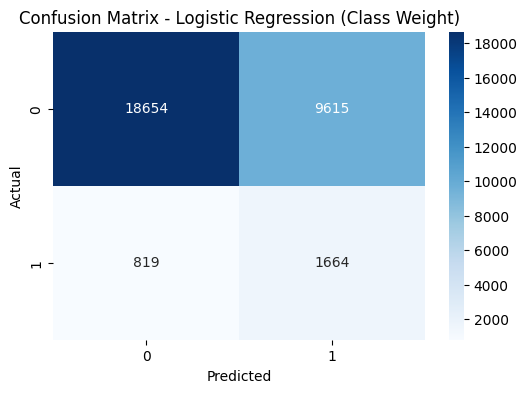


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.66      0.78     28269
           1       0.15      0.67      0.24      2483

    accuracy                           0.66     30752
   macro avg       0.55      0.67      0.51     30752
weighted avg       0.89      0.66      0.74     30752



In [75]:
metrics_lr = evaluate_model(logistic_model, X_val, y_val, "Logistic Regression (Class Weight)")
all_model_metrics.append(metrics_lr)

# 6.2. Logistic regression (SMOTE Balanced)


--- Evaluating Logistic Regression (SMOTE) ---
ROC-AUC: 0.6626
PR-AUC: 0.1654
Accuracy: 0.9067
Precision: 0.2666
Recall: 0.0890
F1-Score: 0.1335

Confusion Matrix:


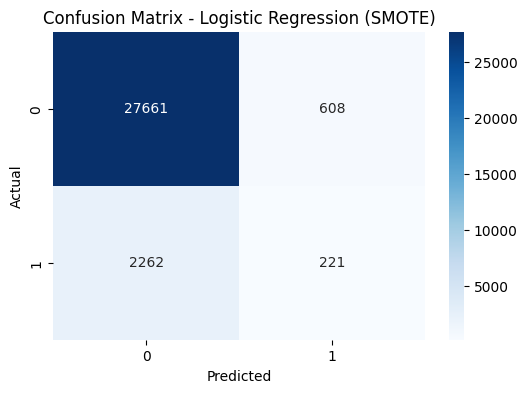


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95     28269
           1       0.27      0.09      0.13      2483

    accuracy                           0.91     30752
   macro avg       0.60      0.53      0.54     30752
weighted avg       0.87      0.91      0.88     30752



In [76]:
metrics_lr_smote = evaluate_model(logistic_model_smote, X_val, y_val, "Logistic Regression (SMOTE)")
all_model_metrics.append(metrics_lr_smote)

# 6.3. Extra Trees (class_weight='balanced')


--- Evaluating Extra Trees (Class Weight) ---
ROC-AUC: 0.6972
PR-AUC: 0.1786
Accuracy: 0.9194
Precision: 0.7500
Recall: 0.0024
F1-Score: 0.0048

Confusion Matrix:


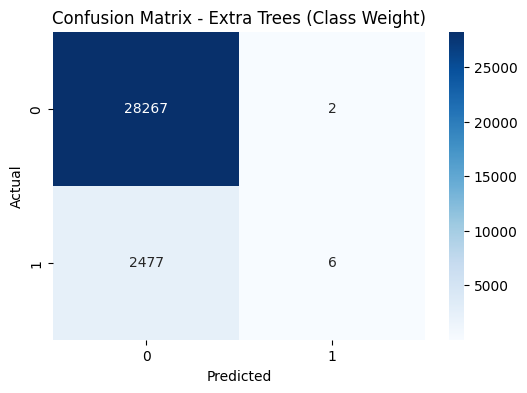


Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     28269
           1       0.75      0.00      0.00      2483

    accuracy                           0.92     30752
   macro avg       0.83      0.50      0.48     30752
weighted avg       0.91      0.92      0.88     30752



In [77]:
metrics_et = evaluate_model(extra_trees_model, X_val, y_val, "Extra Trees (Class Weight)")
all_model_metrics.append(metrics_et)

# 6.4. Extra Trees (SMOTE Balanced)


--- Evaluating Extra Trees (SMOTE) ---
ROC-AUC: 0.6801
PR-AUC: 0.1587
Accuracy: 0.9151
Precision: 0.2705
Recall: 0.0306
F1-Score: 0.0550

Confusion Matrix:


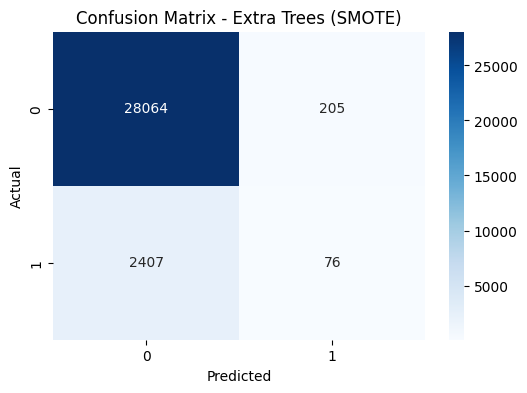


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96     28269
           1       0.27      0.03      0.05      2483

    accuracy                           0.92     30752
   macro avg       0.60      0.51      0.51     30752
weighted avg       0.87      0.92      0.88     30752



In [78]:
metrics_et_smote = evaluate_model(extra_trees_model_smote, X_val, y_val, "Extra Trees (SMOTE)")
all_model_metrics.append(metrics_et_smote)

# 6.5. XGBoost (class_weight='balanced')


--- Evaluating XGBoost (Class Weight) ---
ROC-AUC: 0.7347
PR-AUC: 0.2190
Accuracy: 0.7353
Precision: 0.1705
Recall: 0.5896
F1-Score: 0.2646

Confusion Matrix:


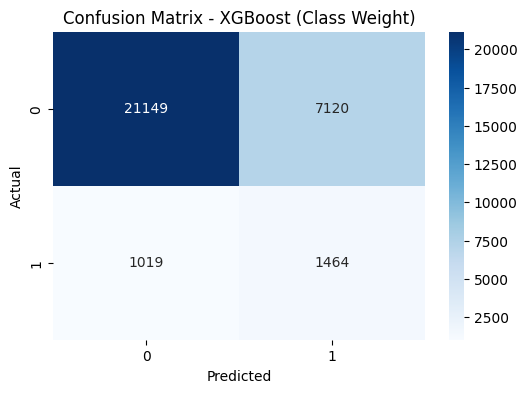


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.75      0.84     28269
           1       0.17      0.59      0.26      2483

    accuracy                           0.74     30752
   macro avg       0.56      0.67      0.55     30752
weighted avg       0.89      0.74      0.79     30752



In [79]:
metrics_xgb = evaluate_model(xgboost_model, X_val, y_val, "XGBoost (Class Weight)")
all_model_metrics.append(metrics_xgb)

# 6.6. XGBoost (SMOTE Balanced)


--- Evaluating XGBoost (SMOTE) ---
ROC-AUC: 0.7283
PR-AUC: 0.2030
Accuracy: 0.9181
Precision: 0.4051
Recall: 0.0318
F1-Score: 0.0590

Confusion Matrix:


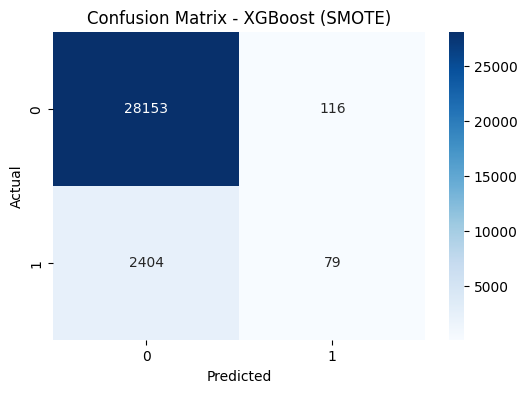


Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     28269
           1       0.41      0.03      0.06      2483

    accuracy                           0.92     30752
   macro avg       0.66      0.51      0.51     30752
weighted avg       0.88      0.92      0.88     30752



In [80]:
metrics_xgb_smote = evaluate_model(xgboost_model_smote, X_val, y_val, "XGBoost (SMOTE)")
all_model_metrics.append(metrics_xgb_smote)

### 6.7. Random Forest (class_weight='balanced') Evaluation


--- Evaluating Random Forest (Class Weight) ---
ROC-AUC: 0.6943
PR-AUC: 0.1796
Accuracy: 0.9193
Precision: 0.6667
Recall: 0.0008
F1-Score: 0.0016

Confusion Matrix:


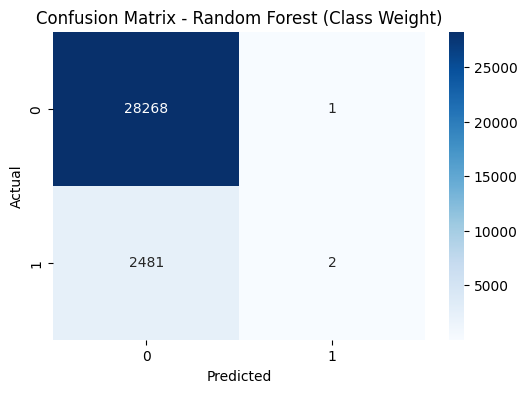


Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     28269
           1       0.67      0.00      0.00      2483

    accuracy                           0.92     30752
   macro avg       0.79      0.50      0.48     30752
weighted avg       0.90      0.92      0.88     30752


--- Model Performance Summary (Updated) ---
                                    roc_auc  pr_auc  accuracy  precision  \
model_name                                                                 
Logistic Regression (Class Weight)   0.7241  0.2006    0.6607     0.1475   
Logistic Regression (SMOTE)          0.6626  0.1654    0.9067     0.2666   
Extra Trees (Class Weight)           0.6972  0.1786    0.9194     0.7500   
Extra Trees (SMOTE)                  0.6801  0.1587    0.9151     0.2705   
XGBoost (Class Weight)               0.7347  0.2190    0.7353     0.1705   
XGBoost (SMOTE)                      0.7283  0.2030    0.9181     0.4051

<Figure size 1400x700 with 0 Axes>

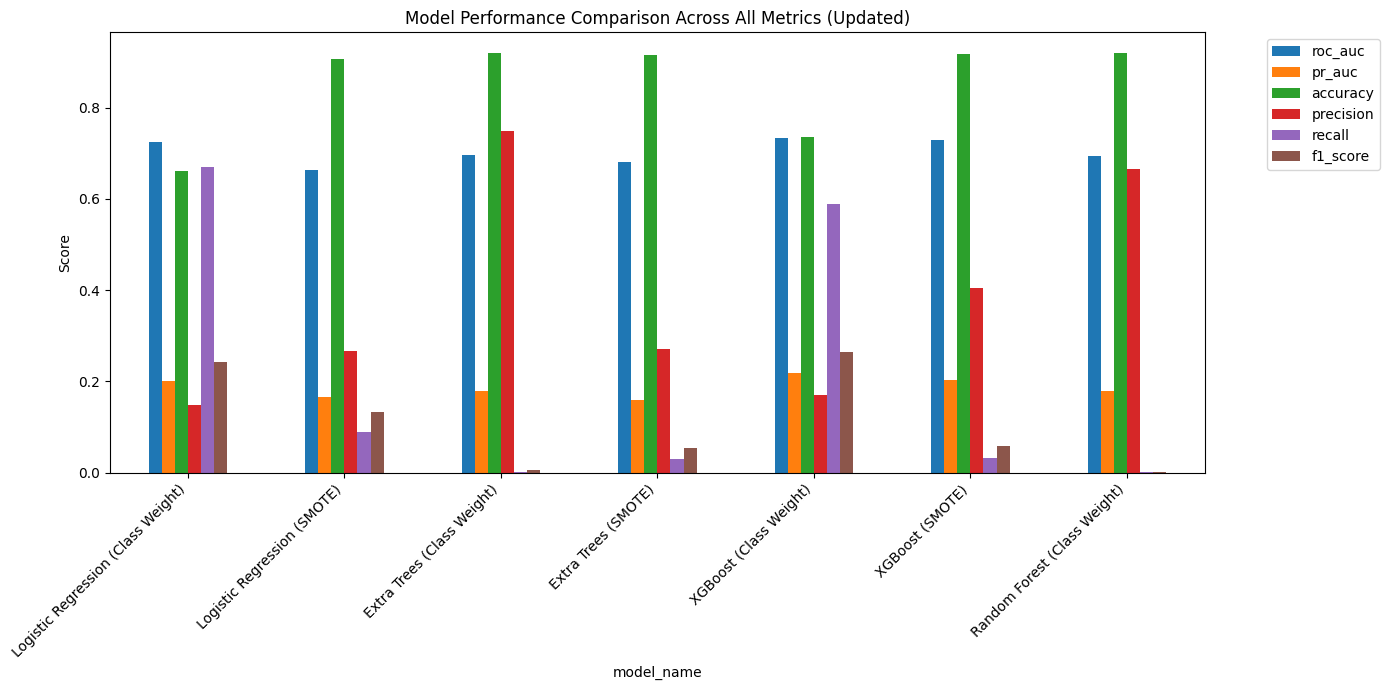

In [81]:
metrics_rf = evaluate_model(random_forest_model, X_val, y_val, "Random Forest (Class Weight)")
all_model_metrics.append(metrics_rf)

metrics_df = pd.DataFrame(all_model_metrics)
metrics_df = metrics_df.set_index('model_name')

print("\n--- Model Performance Summary (Updated) ---")
print(metrics_df.round(4))

plt.figure(figsize=(14, 7))
metrics_df[['roc_auc', 'pr_auc', 'accuracy', 'precision', 'recall', 'f1_score']].plot(kind='bar', figsize=(14, 7))
plt.title('Model Performance Comparison Across All Metrics (Updated)')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 7. Evaluacija


--- Model Performance Summary ---
                                    roc_auc  pr_auc  accuracy  precision  \
model_name                                                                 
Logistic Regression (Class Weight)   0.7241  0.2006    0.6607     0.1475   
Logistic Regression (SMOTE)          0.6626  0.1654    0.9067     0.2666   
Extra Trees (Class Weight)           0.6972  0.1786    0.9194     0.7500   
Extra Trees (SMOTE)                  0.6801  0.1587    0.9151     0.2705   
XGBoost (Class Weight)               0.7347  0.2190    0.7353     0.1705   
XGBoost (SMOTE)                      0.7283  0.2030    0.9181     0.4051   
Random Forest (Class Weight)         0.6943  0.1796    0.9193     0.6667   

                                    recall  f1_score  
model_name                                            
Logistic Regression (Class Weight)  0.6702    0.2418  
Logistic Regression (SMOTE)         0.0890    0.1335  
Extra Trees (Class Weight)          0.0024    0.0048  
Extra

<Figure size 1400x700 with 0 Axes>

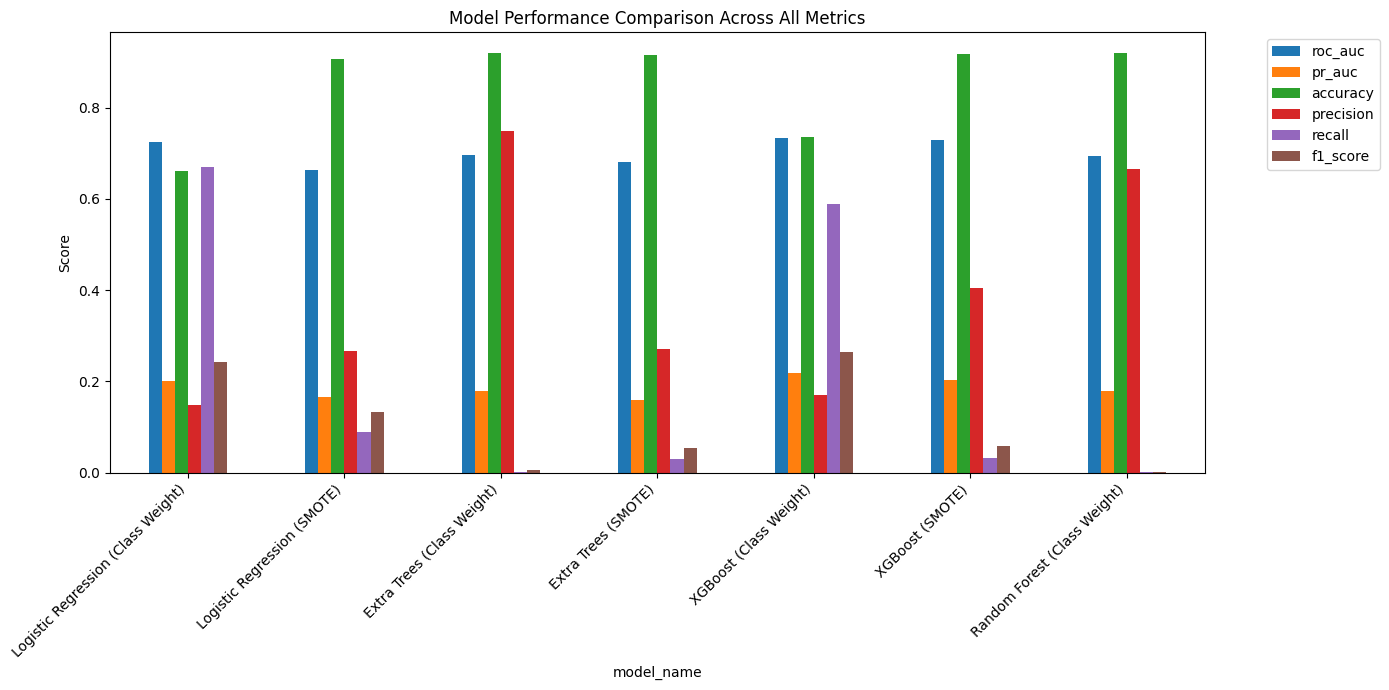

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

metrics_df = pd.DataFrame(all_model_metrics)
metrics_df = metrics_df.set_index('model_name')

print("\n--- Model Performance Summary ---")
print(metrics_df.round(4))

plt.figure(figsize=(14, 7))
metrics_df[['roc_auc', 'pr_auc', 'accuracy', 'precision', 'recall', 'f1_score']].plot(kind='bar', figsize=(14, 7))
plt.title('Model Performance Comparison Across All Metrics')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Analiza evaluacijskih metrika
### Zašto Accuracy nije dovoljna metrika za ovaj problem?

Kod problema s neuravnoteženim klasama, kao što je ovaj (manjinska klasa oko 8%), **accuracy (točnost)** je zavaravajuća. Visoka točnost može proizaći iz toga što model jednostavno predviđa većinsku klasu, zanemarujući manjinsku. Stoga su metrike poput **Precisiona, Recalla, F1-scorea, ROC-AUC-a i PR-AUC-a** ključne jer mjere sposobnost modela da pravilno identificira manjinsku klasu.

### Utjecaj tehnika balansiranja na Precision, Recall i F1-score

**Cilj balansiranja klasa** je poboljšati **Recall** manjinske klase, često nauštrb **Precisiona**. **F1-score** traži ravnotežu.

*   **Class Weighting (uključujući `scale_pos_weight` za XGBoost):** Ova tehnika je konzistentno rezultirala **višim Recallom** za manjinsku klasu (npr. kod Logistic Regression i XGBoost), iako često s nižim Precisionom. **XGBoost s `scale_pos_weight`** postigao je **najbolji F1-score i PR-AUC**, pokazujući najbolju ravnotežu između Precisiona i Recalla.

*   **SMOTE:** U većini testiranih modela, SMOTE je doveo do **vrlo niskog Recalla** i **niskog F1-scorea**. To sugerira da ova tehnika nije bila učinkovita za ovaj skup podataka, moguće zbog generiranja 'šuma' ili prekomjernog prilagođavanja na sintetičke uzorke. Modeli trenirani sa SMOTE-om nisu uspjeli značajno poboljšati detekciju manjinske klase.

# 8. Threshold tuning

In [91]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_threshold(model, X_val, y_val, threshold):
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    precision = precision_score(y_val, y_pred_threshold)
    recall = recall_score(y_val, y_pred_threshold)
    f1 = f1_score(y_val, y_pred_threshold)

    risky_clients_predicted = np.sum(y_pred_threshold == 1)
    truly_risky_clients_found = np.sum((y_val == 1) & (y_pred_threshold == 1))

    print(f"\n--- Threshold: {threshold:.2f} ---")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Number of clients identified as risky: {risky_clients_predicted}")
    print(f"Number of truly risky clients found by model: {truly_risky_clients_found}")

    return { 'threshold': threshold, 'precision': precision, 'recall': recall, 'f1_score': f1, 'risky_clients_predicted': risky_clients_predicted, 'truly_risky_clients_found': truly_risky_clients_found }

thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]
threshold_results = []

for t in thresholds:
    results = evaluate_threshold(xgboost_model, X_val, y_val, t)
    threshold_results.append(results)



--- Threshold: 0.20 ---
Precision: 0.1013
Recall: 0.9255
F1-Score: 0.1827
Number of clients identified as risky: 22675
Number of truly risky clients found by model: 2298

--- Threshold: 0.30 ---
Precision: 0.1184
Recall: 0.8292
F1-Score: 0.2071
Number of clients identified as risky: 17397
Number of truly risky clients found by model: 2059

--- Threshold: 0.40 ---
Precision: 0.1420
Recall: 0.7197
F1-Score: 0.2372
Number of clients identified as risky: 12586
Number of truly risky clients found by model: 1787

--- Threshold: 0.50 ---
Precision: 0.1705
Recall: 0.5896
F1-Score: 0.2646
Number of clients identified as risky: 8584
Number of truly risky clients found by model: 1464

--- Threshold: 0.60 ---
Precision: 0.2090
Recall: 0.4563
F1-Score: 0.2867
Number of clients identified as risky: 5421
Number of truly risky clients found by model: 1133

--- Threshold: 0.70 ---
Precision: 0.2593
Recall: 0.2956
F1-Score: 0.2763
Number of clients identified as risky: 2831
Number of truly risky client

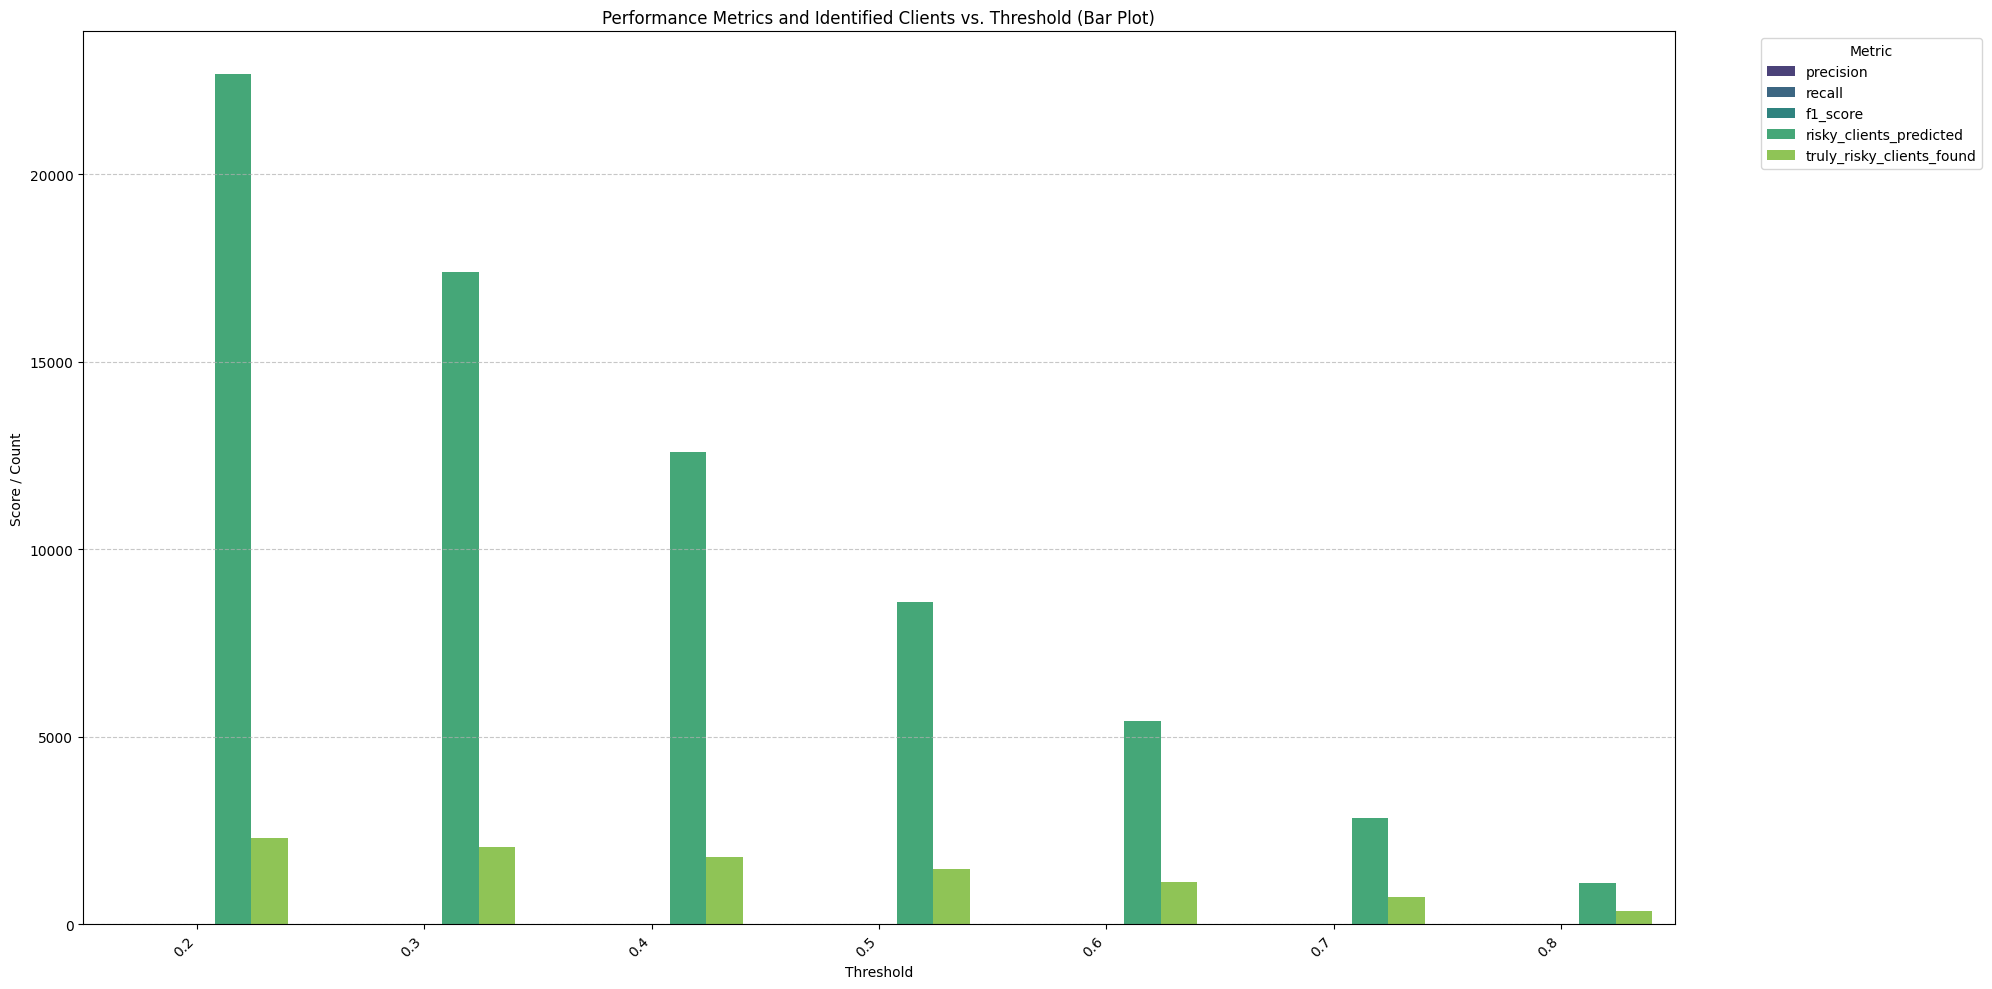

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

threshold_df = pd.DataFrame(threshold_results)

threshold_melted = threshold_df.melt(id_vars=['threshold'],
                                     value_vars=['precision', 'recall', 'f1_score', 'risky_clients_predicted', 'truly_risky_clients_found'],
                                     var_name='Metric', value_name='Score')

plt.figure(figsize=(20, 10))
sns.barplot(x='threshold', y='Score', hue='Metric', data=threshold_melted, palette='viridis')

plt.title('Performance Metrics and Identified Clients vs. Threshold (Bar Plot)')
plt.xlabel('Threshold')
plt.ylabel('Score / Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Iz slike je jasno vidljivo da sa višim thresholdom recall pada, precision raste, dok f1_score konvergira negdje oko 0.6, iako je f1_score značajan i sugerira da je 0.6 najbolji model odabrani threshold je 0.5 zbog značajnosti recall metrike u poslovnom kontekstu (manji financijski gubitci)

# 9. Interpretacija modela

Explaining model predictions with SHAP...
SHAP values calculated. Generating summary plot...


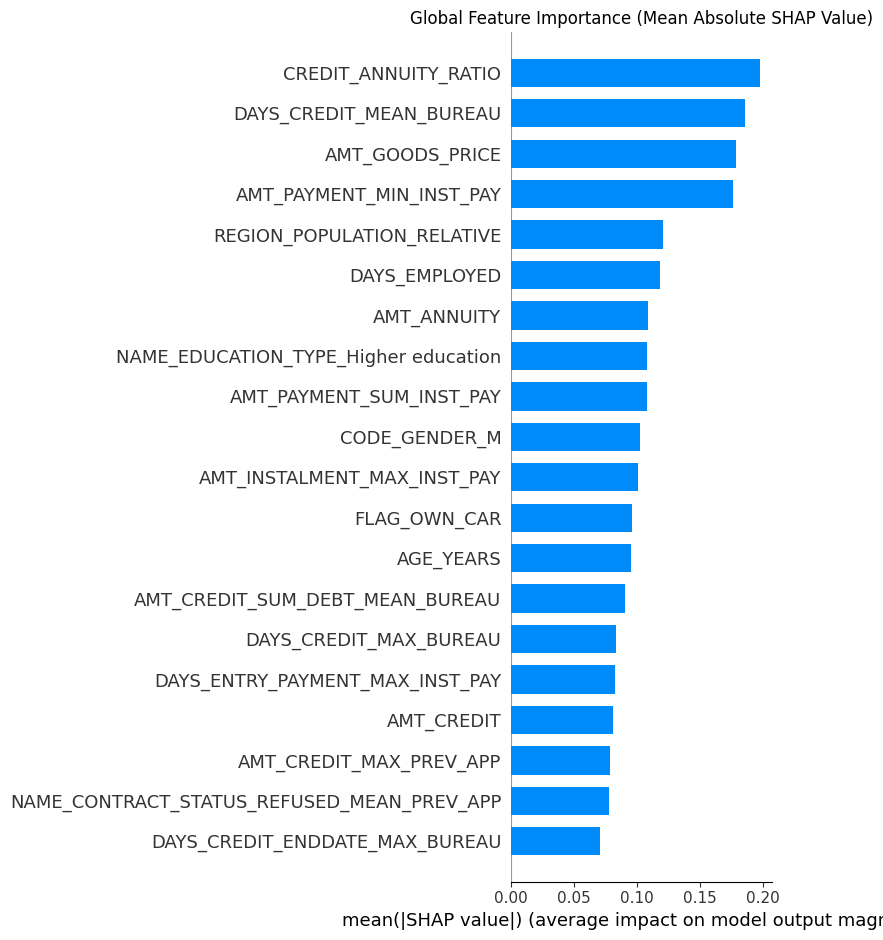

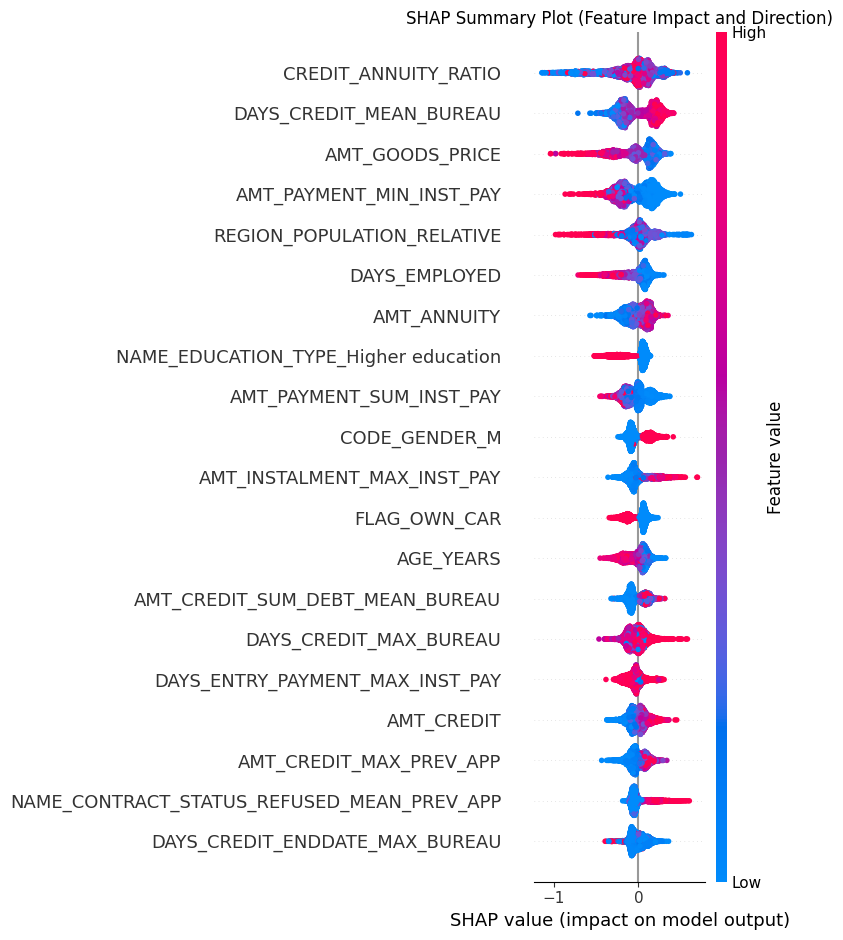

In [95]:
import shap
import matplotlib.pyplot as plt

shap.initjs()

sample_size = 5000
X_val_sample = X_val.sample(n=min(len(X_val), sample_size), random_state=42)

print("Explaining model predictions with SHAP...")

explainer = shap.TreeExplainer(xgboost_model)

shap_values = explainer.shap_values(X_val_sample)

print("SHAP values calculated. Generating summary plot...")

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val_sample, plot_type="bar", show=False)
plt.title('Global Feature Importance (Mean Absolute SHAP Value)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_val_sample, show=False)
plt.title('SHAP Summary Plot (Feature Impact and Direction)')
plt.tight_layout()
plt.show()

In [99]:
import pandas as pd
import numpy as np

shap_importance = pd.DataFrame({
    'feature': X_val_sample.columns,
    'mean_abs_shap_value': np.abs(shap_values).mean(axis=0),
    'mean_shap_value': shap_values.mean(axis=0)
})
shap_importance = shap_importance.sort_values(by='mean_abs_shap_value', ascending=False).reset_index(drop=True)

print("\nTop 10 Most Important Features based on SHAP (with direction):")
print(shap_importance.head(10))


Top 10 Most Important Features based on SHAP (with direction):
                                feature  mean_abs_shap_value  mean_shap_value
0                  CREDIT_ANNUITY_RATIO             0.197131        -0.073553
1               DAYS_CREDIT_MEAN_BUREAU             0.185428        -0.020429
2                       AMT_GOODS_PRICE             0.178680        -0.017615
3              AMT_PAYMENT_MIN_INST_PAY             0.176132        -0.034005
4            REGION_POPULATION_RELATIVE             0.120515        -0.019601
5                         DAYS_EMPLOYED             0.118204        -0.021770
6                           AMT_ANNUITY             0.108512        -0.012966
7  NAME_EDUCATION_TYPE_Higher education             0.107825        -0.014946
8              AMT_PAYMENT_SUM_INST_PAY             0.107743        -0.024088
9                         CODE_GENDER_M             0.102098        -0.011999


### Poslovna interpretacija top 10 najvažnijih značajki:

Na temelju SHAP analize, evo interpretacije top 10 najvažnijih značajki za predviđanje kreditnog rizika:

1.  **CREDIT_ANNUITY_RATIO (Omjer kredita i anuiteta):** Ovaj omjer ukazuje na to koliko su veliki ukupni krediti u odnosu na mjesečne anuitete. Visok omjer može značiti dugoročnije obveze ili veće ukupno opterećenje, što može povećati rizik otplate.

2.  **DAYS_CREDIT_MEAN_BUREAU (Prosječni dani trajanja kredita u kreditnom birou):** Ova značajka odražava prosječnu starost ili trajanje prethodnih kredita klijenta. Dulje pozitivno kreditno iskustvo (niža negativna vrijednost) može ukazivati na stabilnijeg klijenta, dok kraće trajanje ili noviji krediti mogu biti povezani s većim rizikom.

3.  **AMT_GOODS_PRICE (Cijena proizvoda za koji je kredit uzet):** Kao i iznos kredita, viša cijena proizvoda za koji se uzima kredit znači i veći iznos kredita, što prirodno povećava financijsku izloženost i potencijalni rizik za banku.

4.  **AMT_PAYMENT_MIN_INST_PAY (Minimalni iznos rate kredita):** Ova značajka vjerojatno ukazuje na financijsku sposobnost klijenta da se nosi s minimalnim obvezama. Klijenti koji imaju niže minimalne rate (ili su ih imali) u prošlosti mogu biti percipirani kao manje rizični, ili obrnuto, vrlo visoke minimalne rate mogu signalizirati opterećenje.

5.  **REGION_POPULATION_RELATIVE (Relativna populacija regije):** Ova značajka može biti indikator ekonomske razvijenosti i stabilnosti regije u kojoj klijent živi. Regije s manjom gustoćom naseljenosti ili nižom ekonomskom aktivnošću mogu biti povezane s većim rizikom zbog potencijalno manje stabilnih tržišta rada i nižih prihoda.

6.  **DAYS_EMPLOYED (Dani zaposlenosti):** Duljina zaposlenja je ključni pokazatelj stabilnosti prihoda. Duže radno iskustvo kod jednog poslodavca ili ukupno duže razdoblje zaposlenosti sugerira stabilnost i manji rizik, dok kraća zaposlenja ili česte promjene posla mogu povećati rizik.

7.  **AMT_ANNUITY (Iznos anuiteta kredita):** Mjesečna rata koju klijent plaća za kredit. Visok anuitet u odnosu na prihode značajno povećava rizik jer ostavlja manje raspoloživog dohotka za životne troškove i druge financijske obveze.

8.  **NAME_EDUCATION_TYPE_Higher education (Visoka stručna sprema):** Klijenti s višom stručnom spremom često imaju stabilnije poslove i veće prihode, što ih čini manje rizičnima. Ova značajka ukazuje na pozitivan utjecaj višeg obrazovanja na kreditnu sposobnost.

9.  **AMT_PAYMENT_SUM_INST_PAY (Ukupni iznos plaćenih rata kredita):** Ukupni zbroj svih plaćenih rata. Veći ukupno plaćeni iznos u prošlosti može ukazivati na to da je klijent uspješno upravljao svojim obvezama, dok niži iznos može ukazivati na probleme s otplatom ili kraću kreditnu povijest.

10. **CODE_GENDER_M (Spol - muškarac):** Spol klijenta može utjecati na kreditni rizik, bilo zbog tendencije ka rizičnim aktivnostima (npr. kockanje) odabiranje niže plaćenih poslova ili nečeg drugog.